In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

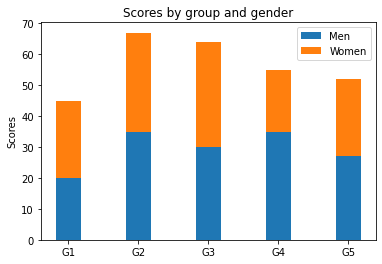

In [14]:
# stacked bar by matplotlib
labels = ['G1', 'G2', 'G3', 'G4', 'G5']
men_means = [20, 35, 30, 35, 27]
women_means = [25, 32, 34, 20, 25]

width = 0.35       # the width of the bars: can also be len(x) sequence

fig, ax = plt.subplots()

ax.bar(labels, men_means, width, label='Men')
ax.bar(labels, women_means, width, bottom=men_means, label='Women')

ax.set_ylabel('Scores')
ax.set_title('Scores by group and gender')
ax.legend()

plt.show()

In [4]:
# create a data example
df = pd.DataFrame(
    columns = ['spring', 'summer', 'fall', 'winter'],
    index = ['Shenyang', 'Dalian', 'Harbin'],
    data = np.random.randint(500, 1000, (3, 4))
)

df

,spring,summer,fall,winter
Shenyang,659,732,509,649
Dalian,634,994,875,651
Harbin,575,768,890,898


In [6]:
df.iloc[0, 1]

732

In [9]:
df.cumsum()

,spring,summer,fall,winter
Shenyang,659,732,509,649
Dalian,1293,1726,1384,1300
Harbin,1868,2494,2274,2198


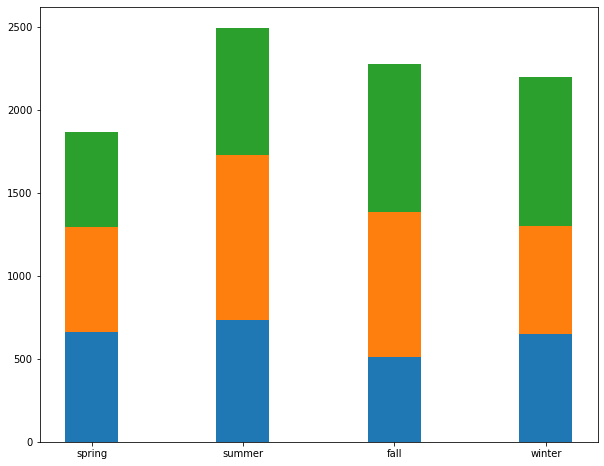

In [11]:
# stacked bar from df

labels = df.columns
width = 0.35       # the width of the bars: can also be len(x) sequence

fig, ax = plt.subplots(figsize=(10, 8))

ax.bar(labels, df.iloc[0], width)
for idx in range(1, len(df)):
    ax.bar(labels, df.iloc[idx], width, bottom=df.cumsum().iloc[idx-1])


plt.show()

In [16]:
# 把绝对值变成相对百分比，以便于直方图累计都是100%高度
df_pos = df / df.sum() # each columns divide to their sum
df_cum = pd.concat(
    [pd.DataFrame(index=['empty'], columns=df.columns),
     df_pos.cumsum()]
).fillna(0) # accoumlated sum
df_cum

,spring,summer,fall,winter
empty,0.000000,0.000000,0.000000,0.000000
Shenyang,0.352784,0.293504,0.223835,0.295268
Dalian,0.692184,0.692061,0.608619,0.591447
Harbin,1.000000,1.000000,1.000000,1.000000


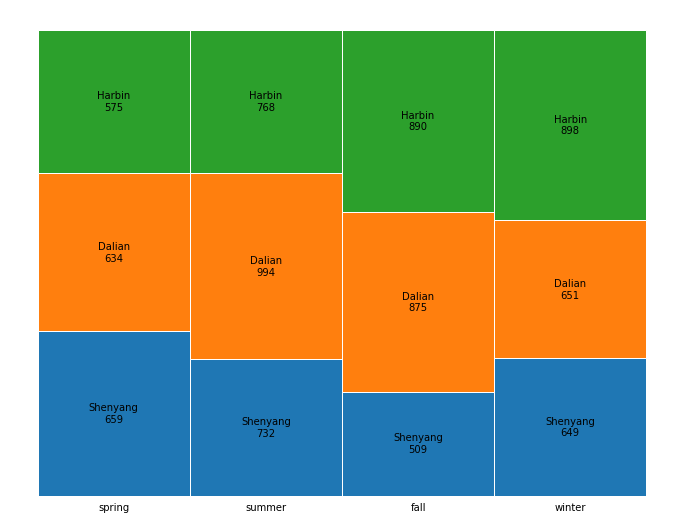

In [19]:
labels = df.columns
df_pos = df / df.sum()
df_cum = pd.concat(
    [pd.DataFrame(index=['empty'], columns=df.columns),
     df_pos.cumsum()]
).fillna(0)
width = 1  # change the width to 100%

fig, ax = plt.subplots(figsize=(12, 9))
for idx in range(len(df)):
    ax.bar(labels, df_pos.iloc[idx], width, bottom=df_cum.iloc[idx], ec="w")

# add lable
for row in range(len(df)):
    for col in range(len(df.columns)):
        y = df_cum.iloc[row, col] + df_pos.iloc[row, col]/2
        s = f"{df.index[row]}\n{df.iloc[row, col]}"
        ax.text(col, y,  s, ha="center", va='center')
        
ax.set(yticklabels=[])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.tick_params(left=False)
ax.tick_params(bottom=False)
plt.show()

# All in All

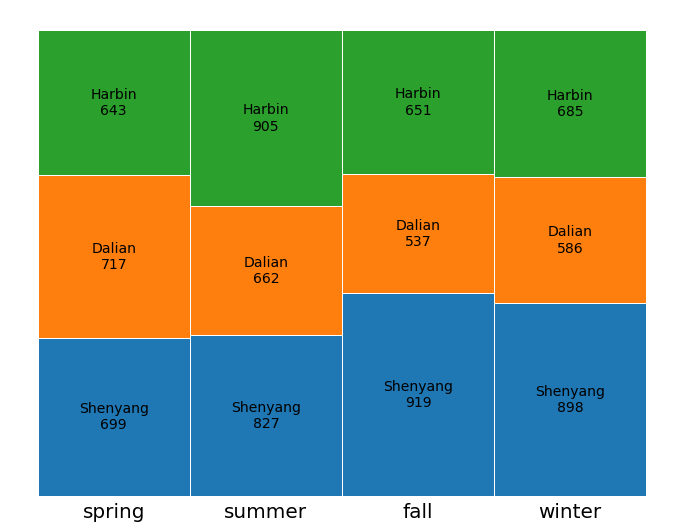

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib 
matplotlib.rc('xtick', labelsize=20) 
# plt.rcParams['font.family'] = ['']

def df2masac(df, ax):
    labels = df.columns
    df_pos = df / df.sum()
    df_cum = pd.concat(
        [pd.DataFrame(index=['empty'], columns=df.columns),
         df_pos.cumsum()]
    ).fillna(0)
    width = 1  # change the width to 100%

    for idx in range(len(df)):
        ax.bar(labels, df_pos.iloc[idx], width, bottom=df_cum.iloc[idx], ec="w")

    # add lable
    for row in range(len(df)):
        for col in range(len(df.columns)):
            y = df_cum.iloc[row, col] + df_pos.iloc[row, col]/2
            s = f"{df.index[row]}\n{df.iloc[row, col]}"
            ax.text(col, y,  s, ha="center", va='center', color='black', size=14)

    ax.set(yticklabels=[])
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(left=False)
    ax.tick_params(bottom=False)
    return ax

    
df = pd.DataFrame(
    columns = ['spring', 'summer', 'fall', 'winter'],
    index = ['Shenyang', 'Dalian', 'Harbin'],
    data = np.random.randint(500, 1000, (3, 4))
)

fig, ax = plt.subplots(figsize=(12, 9))

ax = df2masac(df, ax)

plt.show()


In [21]:
from itertools import product
tuples = list(product(['城镇', '乡村'],
              ['室内冰雪运动','室外冰雪运动']))
index = pd.MultiIndex.from_tuples(tuples, names = ['first', 'second'])
data = pd.Series([2.21, 2.68, 0.87, 0.77], index = index)
data.unstack()

second,室内冰雪运动,室外冰雪运动
first,,
乡村,0.87,0.77
城镇,2.21,2.68


/home/karibu/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 23460 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/home/karibu/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 20869 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/home/karibu/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 20912 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/home/karibu/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 38634 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/home/karibu/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 36816 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/home/karibu/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py

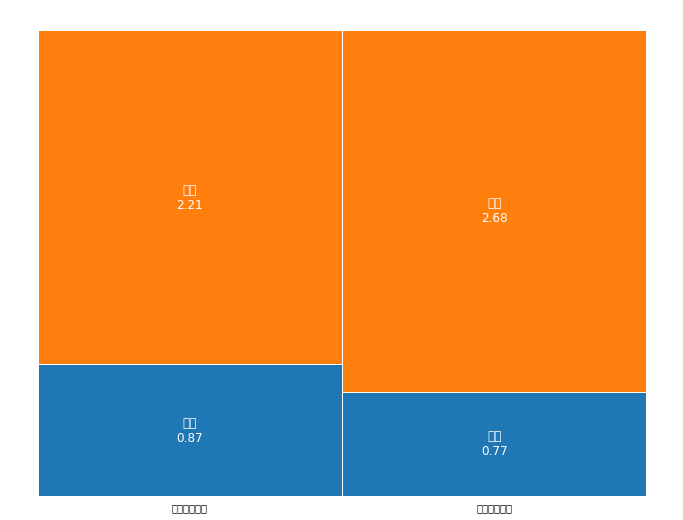

In [22]:
   
df = data.unstack()
fig, ax = plt.subplots(figsize=(12, 9))
ax = df2masac(df, ax)

plt.show()